In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,accuracy_score,classification_report,confusion_matrix
from sklearn.neural_network import MLPClassifier,MLPRegressor

In [31]:
data = pd.read_csv("airlines_delay.csv")

In [32]:
data.head(5)

,Flight,Time,Length,Airline,AirportFrom,AirportTo,DayOfWeek,Class
0,2313.0,1296.0,141.0,DL,ATL,HOU,1,0
1,6948.0,360.0,146.0,OO,COS,ORD,4,0
2,1247.0,1170.0,143.0,B6,BOS,CLT,3,0
3,31.0,1410.0,344.0,US,OGG,PHX,6,0
4,563.0,692.0,98.0,FL,BMI,ATL,4,0


In [33]:
data.Flight = data.Flight.astype(int)
data.set_index('Flight',inplace = True)
data.head()

,Time,Length,Airline,AirportFrom,AirportTo,DayOfWeek,Class
Flight,,,,,,,
2313,1296.0,141.0,DL,ATL,HOU,1,0
6948,360.0,146.0,OO,COS,ORD,4,0
1247,1170.0,143.0,B6,BOS,CLT,3,0
31,1410.0,344.0,US,OGG,PHX,6,0
563,692.0,98.0,FL,BMI,ATL,4,0


In [34]:
data.dtypes

Time           float64
Length         float64
Airline         object
AirportFrom     object
AirportTo       object
DayOfWeek        int64
Class            int64
dtype: object

In [35]:
data.isnull().sum()

Time           0
Length         0
Airline        0
AirportFrom    0
AirportTo      0
DayOfWeek      0
Class          0
dtype: int64

In [36]:
data.index.duplicated().sum()

532797

In [37]:
#Reset the index before dropping because index Flight is not unique
data.reset_index(inplace=True)
indexes_to_drop = data[data['Length'] <= 0].index
print(f"Number of rows to drop: {len(indexes_to_drop)}")
data.drop(index=indexes_to_drop, inplace=True)
#Set the index again
data.Flight = data.Flight.astype(int)
data.set_index('Flight',inplace=True)
#Let's see the size of our dataset
print(f"New dataset shape: {data.shape}")

Number of rows to drop: 4
New dataset shape: (539378, 7)


In [38]:
for col in data.columns:
    if col in ['Time','Length','Class']:
        next
    else:
        data[col] = data[col].astype('category')
data.dtypes

Time            float64
Length          float64
Airline        category
AirportFrom    category
AirportTo      category
DayOfWeek      category
Class             int64
dtype: object

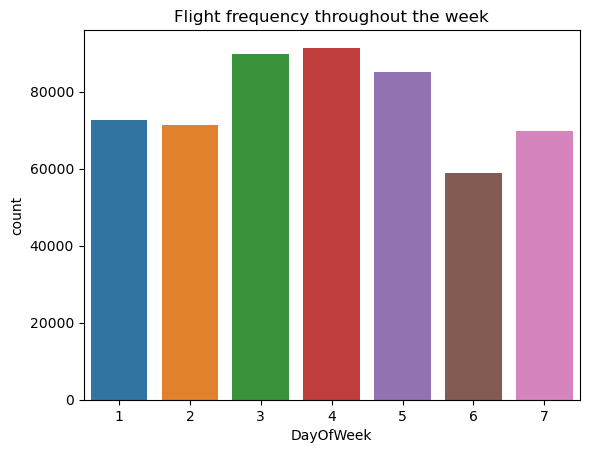

In [39]:
day = list(range(1,8))
sns.countplot(x = 'DayOfWeek',data = data,order = day)
plt.title("Flight frequency throughout the week")
plt.show()

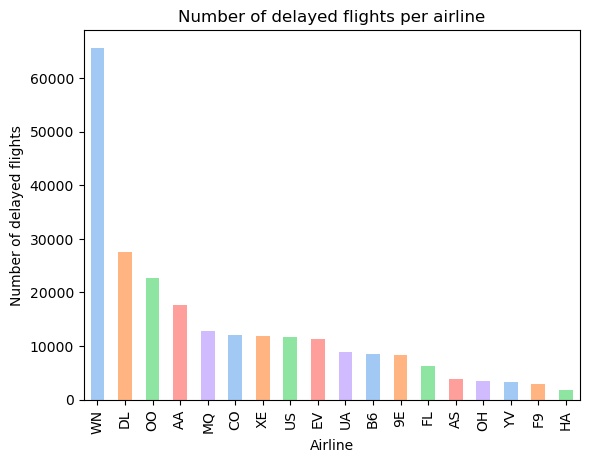

In [40]:
#We will now look at which airlines had the most delayed flights
myColours = sns.color_palette('pastel')[0:5]
c = data.groupby('Airline')['Class'].sum().sort_values(ascending=False)
c.plot(kind='bar',color=myColours)
plt.ylabel('Number of delayed flights')
plt.title('Number of delayed flights per airline')
plt.show()

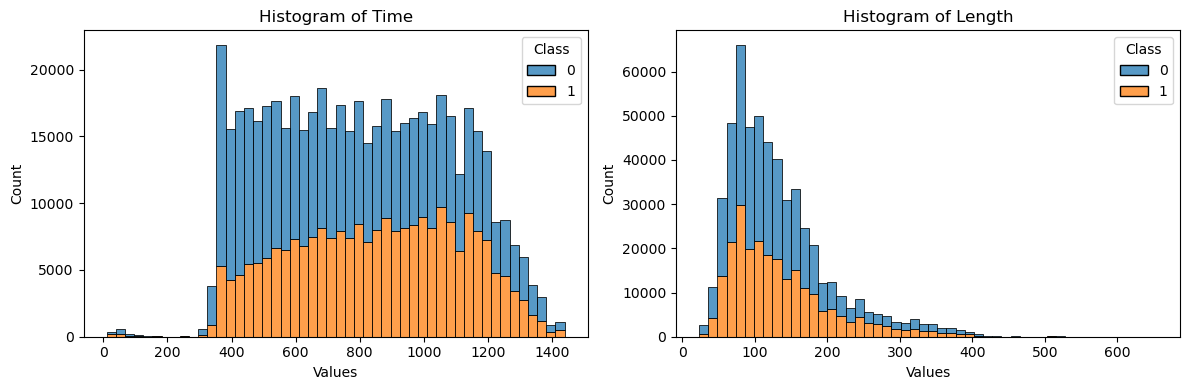

In [41]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
#Histogram of feature Time
sns.histplot(data=data,x=data.Time,ax=axs[0],bins=50, hue='Class',multiple='stack');
axs[0].set_xlabel("Values")
axs[0].set_title('Histogram of Time')

#Histogram of feature Length
sns.histplot(data=data,x=data.Length,ax=axs[1],bins=50, hue='Class',multiple='stack');
axs[1].set_xlabel("Values")
axs[1].set_title('Histogram of Length')
plt.tight_layout()
plt.show()

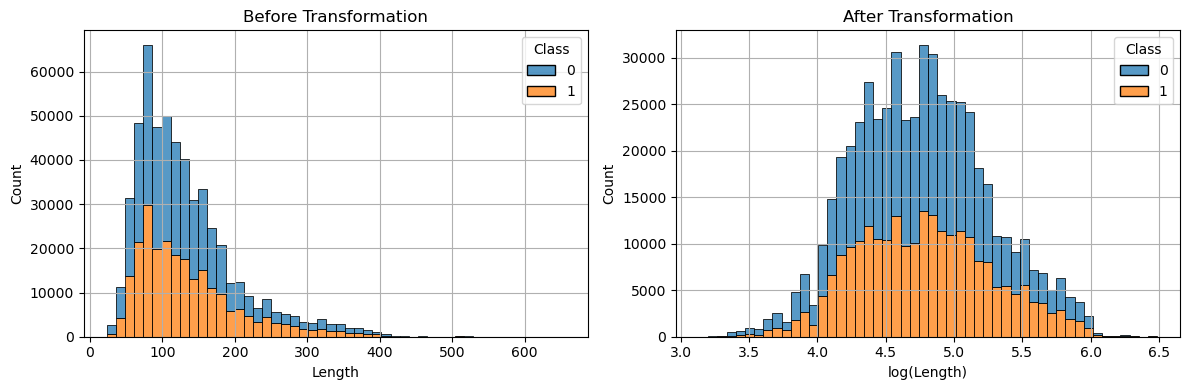

In [42]:
data['Length_Log'] = np.log(data['Length'])
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
#Plotting histogram of Length before transformation
sns.histplot(data=data, x='Length', bins=50,ax=axs[0], hue='Class', multiple='stack')
axs[0].set_title('Before Transformation')
axs[0].set_xlabel('Length')
axs[0].set_ylabel('Count')
axs[0].grid(True)

#Plotting histogram of Length after Log transformation
sns.histplot(data=data,x='Length_Log', bins=50,ax=axs[1], hue='Class', multiple='stack')
axs[1].set_title('After Transformation')
axs[1].set_xlabel('log(Length)')
axs[1].set_ylabel('Count')
axs[1].grid(True)
plt.tight_layout()
plt.show()

In [43]:
data['Length'] = data['Length_Log']
data.drop(columns='Length_Log',inplace=True)
data.head()

,Time,Length,Airline,AirportFrom,AirportTo,DayOfWeek,Class
Flight,,,,,,,
2313,1296.0,4.948760,DL,ATL,HOU,1,0
6948,360.0,4.983607,OO,COS,ORD,4,0
1247,1170.0,4.962845,B6,BOS,CLT,3,0
31,1410.0,5.840642,US,OGG,PHX,6,0
563,692.0,4.584967,FL,BMI,ATL,4,0


In [46]:
categorical_features = ['Airline','AirportFrom','AirportTo','DayOfWeek']
data_cols = pd.get_dummies(data = data,columns = categorical_features,drop_first = True,dtype = 'int')

In [48]:
data.head()

,Time,Length,Airline,AirportFrom,AirportTo,DayOfWeek,Class
Flight,,,,,,,
2313,1296.0,4.948760,DL,ATL,HOU,1,0
6948,360.0,4.983607,OO,COS,ORD,4,0
1247,1170.0,4.962845,B6,BOS,CLT,3,0
31,1410.0,5.840642,US,OGG,PHX,6,0
563,692.0,4.584967,FL,BMI,ATL,4,0


In [49]:
from sklearn.preprocessing import StandardScaler
X = data[['Time','Length','DayOfWeek']]
y = data['Class']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [61]:
import warnings
warnings.filterwarnings('ignore')
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer = 'adam',loss = 'mse',metrics = ['mae'])
model.fit(X_train,y_train,epochs = 10,batch_size = 32,validation_split = 0.1)
loss,mae = model.evaluate(X_test,y_test)
print('Mean Absolute Error:',mae)

# Calculate RMSE
from sklearn.metrics import mean_squared_error
rmse = mean_squared_error(y_test, model.predict(X_test), squared=False)
print('Root Mean Squared Error:', rmse)

# Calculate R-squared
from sklearn.metrics import r2_score
r2 = r2_score(y_test, model.predict(X_test))
print('R-squared:', r2)

Epoch 1/10
12136/12136 [==============================] - 13s 1ms/step - loss: 0.2410 - mae: 0.4784 - val_loss: 0.2383 - val_mae: 0.4788
Epoch 2/10
12136/12136 [==============================] - 13s 1ms/step - loss: 0.2391 - mae: 0.4777 - val_loss: 0.2376 - val_mae: 0.4759
Epoch 3/10
12136/12136 [==============================] - 12s 1ms/step - loss: 0.2388 - mae: 0.4772 - val_loss: 0.2374 - val_mae: 0.4761
Epoch 4/10
12136/12136 [==============================] - 12s 996us/step - loss: 0.2387 - mae: 0.4769 - val_loss: 0.2378 - val_mae: 0.4781
Epoch 5/10
12136/12136 [==============================] - 14s 1ms/step - loss: 0.2386 - mae: 0.4768 - val_loss: 0.2377 - val_mae: 0.4784
Epoch 6/10
12136/12136 [==============================] - 12s 1ms/step - loss: 0.2387 - mae: 0.4770 - val_loss: 0.2380 - val_mae: 0.4808
Epoch 7/10
12136/12136 [==============================] - 12s 1ms/step - loss: 0.2386 - mae: 0.4768 - val_loss: 0.2380 - val_mae: 0.4787
Epoch 8/10
12136/12136 [===============

In [62]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l1,l2
import tensorflow as tf

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],),kernel_regularizer=l2(0.01)),
    Dropout(0.2),
    Dense(32, activation='relu',kernel_regularizer=l1(0.01)),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer = 'adam',loss = 'mse',metrics = ['mae'])
model.fit(X_train,y_train,epochs = 10,batch_size = 32,validation_split = 0.1, callbacks=[early_stopping],verbose = 1)
loss,mae = model.evaluate(X_test,y_test)
print('Mean Absolute Error:',mae)

# Calculate RMSE
from sklearn.metrics import mean_squared_error
rmse = mean_squared_error(y_test, model.predict(X_test), squared=False)
print('Root Mean Squared Error:', rmse)

# Calculate R-squared
from sklearn.metrics import r2_score
r2 = r2_score(y_test, model.predict(X_test))
print('R-squared:', r2)

Epoch 1/10
12136/12136 [==============================] - 13s 1ms/step - loss: 0.2739 - mae: 0.4935 - val_loss: 0.2496 - val_mae: 0.4928
Epoch 2/10
12136/12136 [==============================] - 12s 1ms/step - loss: 0.2494 - mae: 0.4939 - val_loss: 0.2492 - val_mae: 0.4943
Epoch 3/10
12136/12136 [==============================] - 12s 1000us/step - loss: 0.2492 - mae: 0.4940 - val_loss: 0.2493 - val_mae: 0.4935
Epoch 4/10
12136/12136 [==============================] - 12s 989us/step - loss: 0.2492 - mae: 0.4940 - val_loss: 0.2493 - val_mae: 0.4944
Epoch 5/10
12136/12136 [==============================] - 12s 988us/step - loss: 0.2492 - mae: 0.4940 - val_loss: 0.2493 - val_mae: 0.4941
Epoch 6/10
12136/12136 [==============================] - 12s 983us/step - loss: 0.2492 - mae: 0.4940 - val_loss: 0.2494 - val_mae: 0.4950
Epoch 7/10
12136/12136 [==============================] - 12s 987us/step - loss: 0.2492 - mae: 0.4940 - val_loss: 0.2492 - val_mae: 0.4942
Epoch 8/10
12136/12136 [======

In [55]:
# Create an MLPRegressor instance
regressor = MLPRegressor(hidden_layer_sizes=(50, 25), activation='relu', solver='adam', random_state=42)

# Train the model
regressor.fit(X_train, y_train)

# Make predictions on the test set
y_pred = regressor.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 0.23776369128089725
R-squared: 0.03775746125534929


In [60]:
# Create an MLPRegressor instance
regressor = MLPRegressor(hidden_layer_sizes=(100, 25), activation='tanh', solver='adam', random_state=42)

# Train the model
regressor.fit(X_train, y_train)

# Make predictions on the test set
y_pred = regressor.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 0.23833353972657223
R-squared: 0.03545125372588176
